In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
csv_filename = "../CleanData/full_train.csv"
df = pd.read_csv(csv_filename)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72968 entries, 0 to 72967
Data columns (total 97 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gid                   72968 non-null  object 
 1   visteam               72968 non-null  object 
 2   hometeam              72968 non-null  object 
 3   site                  72968 non-null  object 
 4   daynight              72968 non-null  int64  
 5   attendance            72968 non-null  int64  
 6   temp                  72968 non-null  float64
 7   windspeed             72968 non-null  float64
 8   vruns                 72968 non-null  int64  
 9   hruns                 72968 non-null  int64  
 10  wteam                 72968 non-null  object 
 11  lteam                 72968 non-null  object 
 12  Home_Away             72968 non-null  int64  
 13  left_on_base          72968 non-null  int64  
 14  bat_doubles           72968 non-null  int64  
 15  bat_triples        

In [32]:
# convert some column types into int
df = df.drop(columns=['Unnamed: 0', 'number'])  # remove redundant columns
for col in ['left_on_base', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'bat_stolen_bases', 'passed_balls_allowed', 'errors_committed', 'stolen_bases', 'salary', 'score_diff']:
    df[col] = df[col].astype(int)

for col in ['gid', 'visteam', 'hometeam', 'site', 'wteam', 'lteam', 'team', 'teamID']:
    df[col] = df[col].astype('category')

df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18242 entries, 0 to 18241
Data columns (total 99 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   gid                   18242 non-null  category      
 1   visteam               18242 non-null  category      
 2   hometeam              18242 non-null  category      
 3   site                  18242 non-null  category      
 4   daynight              18242 non-null  int64         
 5   attendance            18242 non-null  int64         
 6   temp                  18242 non-null  float64       
 7   windspeed             18242 non-null  float64       
 8   season                18242 non-null  int64         
 9   vruns                 18242 non-null  int64         
 10  hruns                 18242 non-null  int64         
 11  wteam                 18242 non-null  category      
 12  lteam                 18242 non-null  category      
 13  team            

In [34]:
# check nulls
df.isna().sum()

gid           0
visteam       0
hometeam      0
site          0
daynight      0
             ..
TOR02         0
WAS10         0
WAS11         0
WIL02         0
score_diff    0
Length: 99, dtype: int64

In [36]:
# summary stats
df.describe(include='all')

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,season,vruns,...,STL10,STP01,SYD01,TOK01,TOR01,TOR02,WAS10,WAS11,WIL02,score_diff
count,18242,18242,18242,18242,18242.000000,18242.000000,18242.000000,18242.000000,18242.000000,18242.000000,...,18242,18242,18242,18242,18242,18242,18242,18242,18242,18242.000000
unique,18242,33,33,64,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,NaN
top,ANA199704250,SFN,CLE,CHI11,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,NaN
freq,1,659,665,657,NaN,NaN,NaN,NaN,NaN,NaN,...,17956,17810,18241,18237,18176,17674,18194,17953,18241,NaN
mean,NaN,NaN,NaN,NaN,0.335380,28727.098673,70.750008,6.787587,2004.768940,4.479114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005317
min,NaN,NaN,NaN,NaN,0.000000,1171.000000,18.242424,-1.000000,1985.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.000000
25%,NaN,NaN,NaN,NaN,0.000000,19696.500000,64.000000,2.227160,1996.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.000000
50%,NaN,NaN,NaN,NaN,0.000000,28695.500000,72.000000,7.000000,2005.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000
75%,NaN,NaN,NaN,NaN,1.000000,37711.750000,80.000000,10.000000,2014.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
max,NaN,NaN,NaN,NaN,1.000000,73957.000000,107.000000,36.000000,2024.000000,24.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000


In [38]:
# check if `gid` is unique
df['gid'].is_unique

True

In [40]:
# Find all duplicated gid values (keeping all instances, not just the second)
duplicates = df[df.duplicated('gid', keep=False)]
duplicates = duplicates.sort_values('gid')
duplicates.head()

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,season,vruns,...,STL10,STP01,SYD01,TOK01,TOR01,TOR02,WAS10,WAS11,WIL02,score_diff


There are 2 records identical: need to remove dupes

In [43]:
# remove duplicates based on `gid`
df = df.drop_duplicates(subset='gid', keep='first')

In [45]:
# Check if 'teamID' and 'team' are equal for all rows
team_match = (df['teamID'] == df['team']).all()
print(f"'teamID' == 'team' for all rows? {team_match}")

'teamID' == 'team' for all rows? True


teamID and team columns are identical: we can keep only one

In [48]:
# Check if 'season' and 'yearID' are equal for all rows
season_match = (df['season'] == df['yearID']).all()
print(f"'season' == 'yearID' for all rows? {season_match}")

'season' == 'yearID' for all rows? True


season and yearID columns are identical: we can keep only one

In [51]:
df = df.drop(columns=['team', 'season'])
df.head()

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,vruns,hruns,...,STL10,STP01,SYD01,TOK01,TOR01,TOR02,WAS10,WAS11,WIL02,score_diff
0,CIN201704050,PHI,CIN,CIN09,0,19944,62.0,5.0,0,2,...,False,False,False,False,False,False,False,False,False,-2
1,ATL200105030,MIL,ATL,ATL02,0,26411,78.0,5.0,5,0,...,False,False,False,False,False,False,False,False,False,-5
2,LAN201904030,SFN,LAN,LOS03,0,51170,61.0,6.0,3,5,...,False,False,False,False,False,False,False,False,False,-2
3,SFN200407020,OAK,SFN,SFO03,0,42586,62.0,21.0,3,7,...,False,False,False,False,False,False,False,False,False,-4
4,TEX199005160,DET,TEX,ARL01,0,14492,92.0,17.0,12,0,...,False,False,False,False,False,False,False,False,False,12


In [53]:
invalid_winners = set((df['wteam'] == df['teamID']) & (df['score_diff'] < 0))
print(f"Invalid winners (where score is positive but team has lost)? {len(invalid_winners) > 1}")

Invalid winners (where score is positive but team has lost)? False


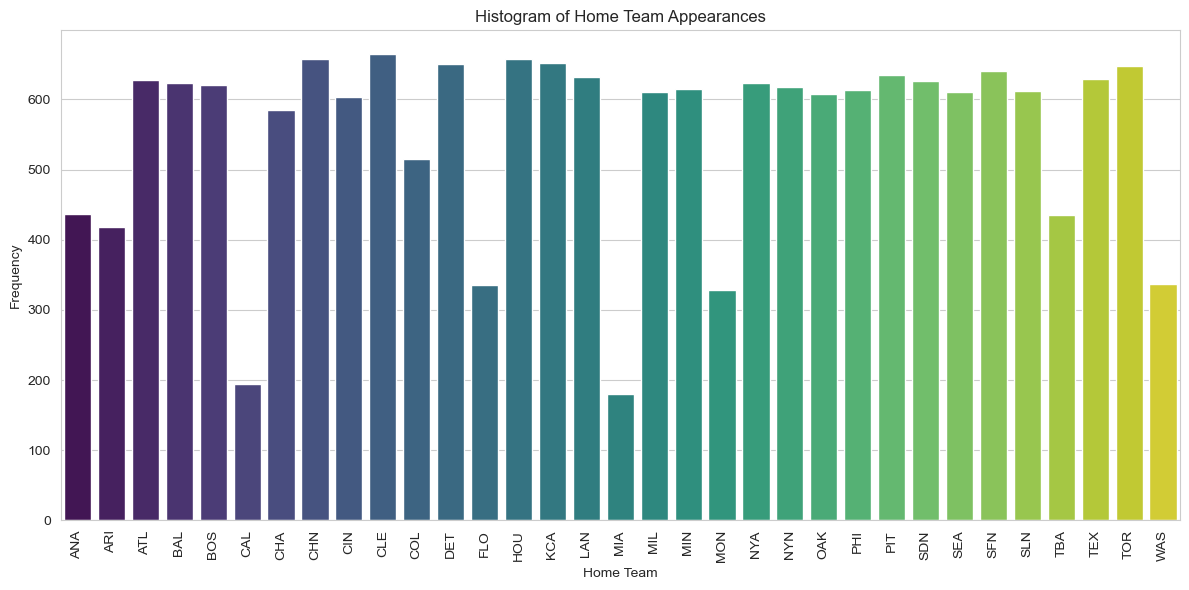

In [57]:
# Count frequencies of each home team
home_counts = df['hometeam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=home_counts.index, y=home_counts.values, palette="viridis", hue=home_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Home Team Appearances")
plt.xlabel("Home Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

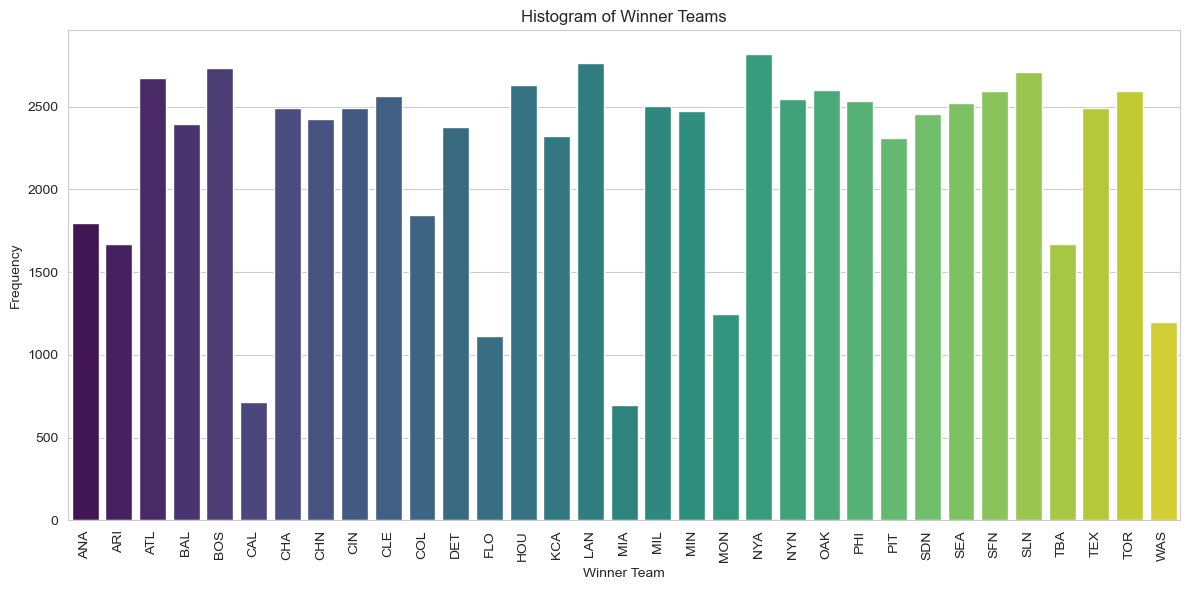

In [34]:
# Count frequencies of each winner team
winner_counts = df['wteam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette="viridis", hue=winner_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Winner Teams")
plt.xlabel("Winner Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

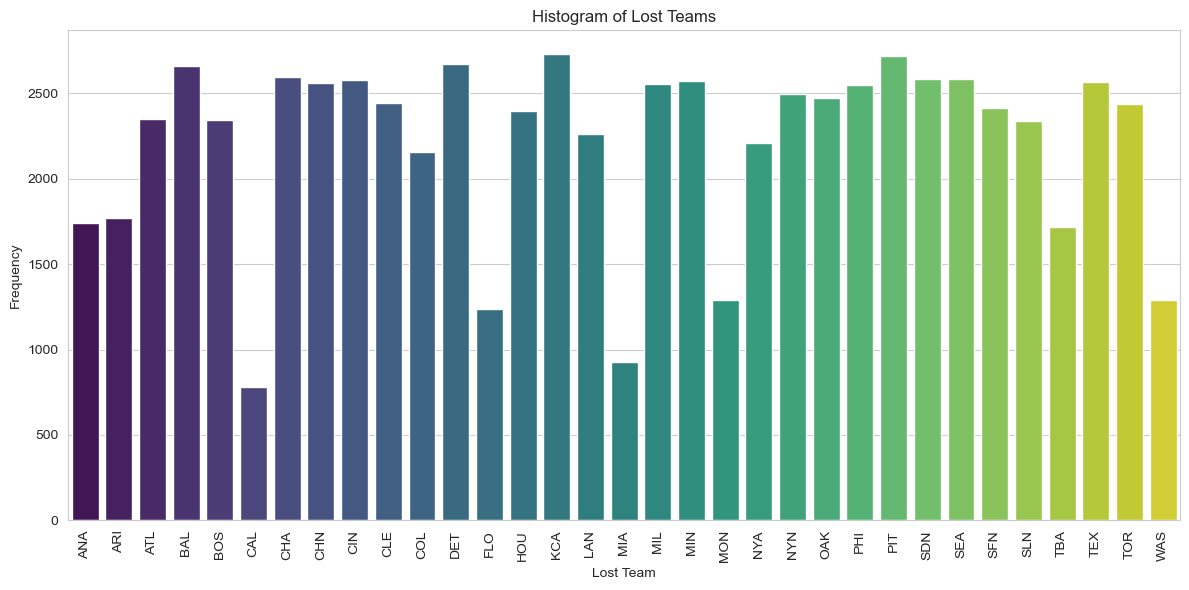

In [36]:
# Count frequencies of each winner team
lost_counts = df['lteam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=lost_counts.index, y=lost_counts.values, palette="viridis", hue=lost_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Lost Teams")
plt.xlabel("Lost Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Weather analysis

In [38]:
# average and min/max temp and windspeed
summary = df[['temp', 'windspeed']].agg(['mean', 'std', 'min', 'max']).round(2)
print(summary)

        temp  windspeed
mean   70.75       6.84
std    13.03       5.67
min    15.98      -1.00
max   113.00      40.00


Correlation

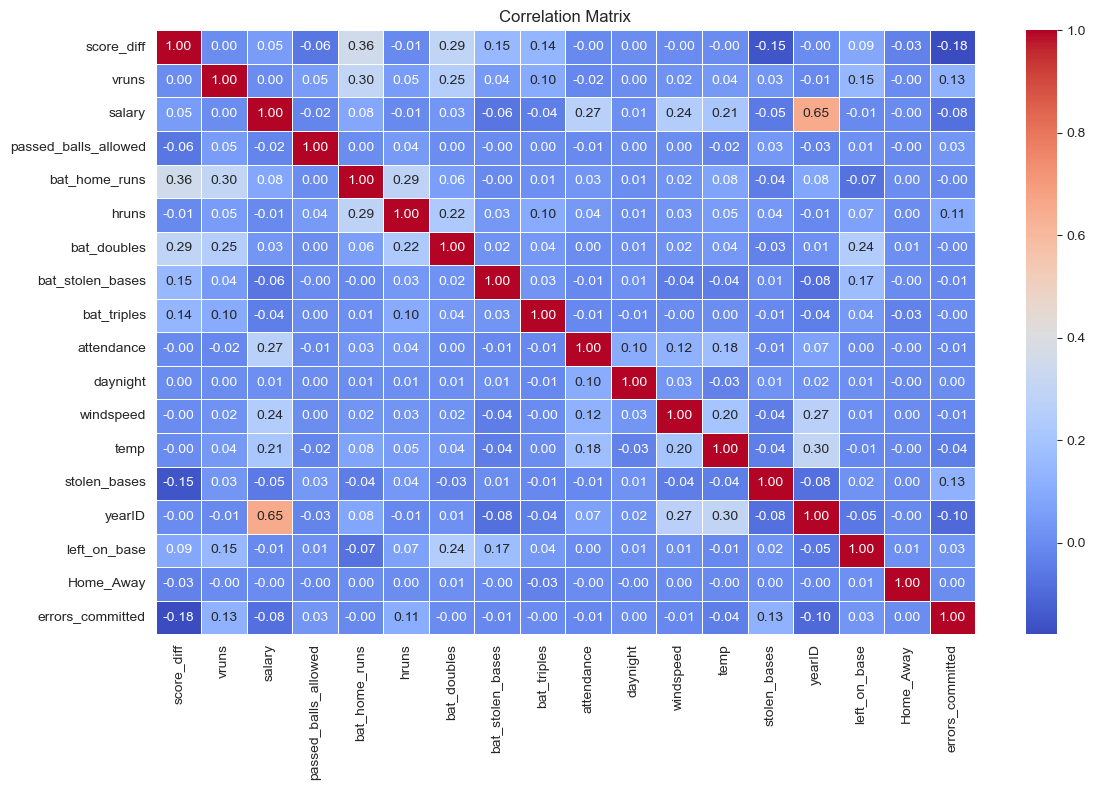

In [40]:
correlation_matrix = df.corr(numeric_only=True)

# Move 'score_diff' to the diagonal position
cols = set(correlation_matrix.columns)
cols = ['score_diff'] + list(cols.difference(['score_diff']))
correlation_matrix = correlation_matrix[cols].loc[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

`bat_home_runs` seems like to have highest correlation.
Does the day or night actually has any impact on score?

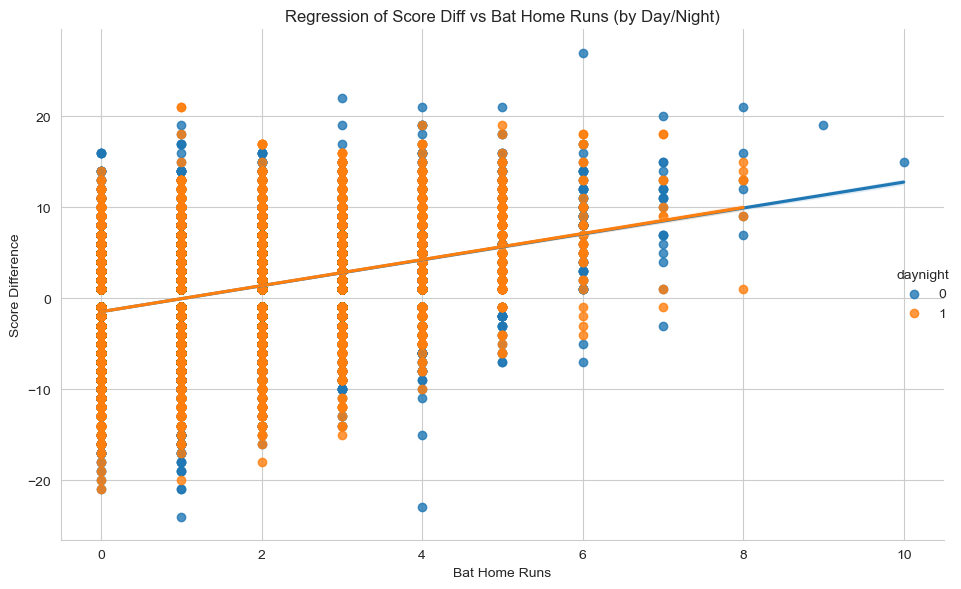

In [46]:
sns.set_style("whitegrid")

# Regression plot
sns.lmplot(
    data=df,
    x='bat_home_runs',
    y='score_diff',
    hue='daynight',
    height=6,
    aspect=1.5
)

plt.title("Regression of Score Diff vs Bat Home Runs (by Day/Night)")
plt.xlabel("Bat Home Runs")
plt.ylabel("Score Difference")
plt.tight_layout()
plt.show()

# no difference

#### APPLY PCA

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# correlation seems to be have between `score_diff` X ['bat_stolen_bases', 'left_on_base', 'Home_Away', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'salary', 'stolen_bases', 'errors_committed', 'passed_balls_allowed']

columns_with_correlation = ['bat_stolen_bases', 'left_on_base', 'Home_Away', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'salary', 'stolen_bases', 'errors_committed', 'passed_balls_allowed']

# pick only numeric columns for PCA
target = 'score_diff'
non_categorical_columns = []
categorical_columns = []
for c in df.columns:
    if c == target:
        continue
    if df[c].dtype == 'object' or df[c].dtype.name == 'category' or c == 'date':
        categorical_columns.append(c)
    else:
        non_categorical_columns.append(c)


# move yearID to the categorical
categorical_columns.append('yearID')
non_categorical_columns.remove('yearID')

print(f"Categorical columns: {categorical_columns}")
print(f"Non-categorical columns: {non_categorical_columns}")


X = df[non_categorical_columns]
y = df[target]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

Categorical columns: ['gid', 'visteam', 'hometeam', 'site', 'wteam', 'lteam', 'date', 'teamID', 'yearID']
Non-categorical columns: ['daynight', 'attendance', 'temp', 'windspeed', 'vruns', 'hruns', 'Home_Away', 'left_on_base', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'bat_stolen_bases', 'passed_balls_allowed', 'errors_committed', 'stolen_bases', 'salary']


(72968, 5)

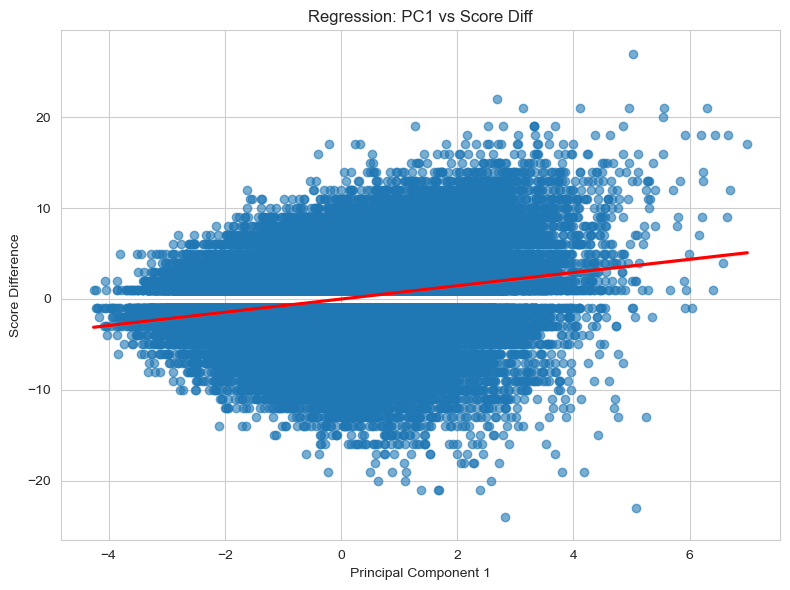

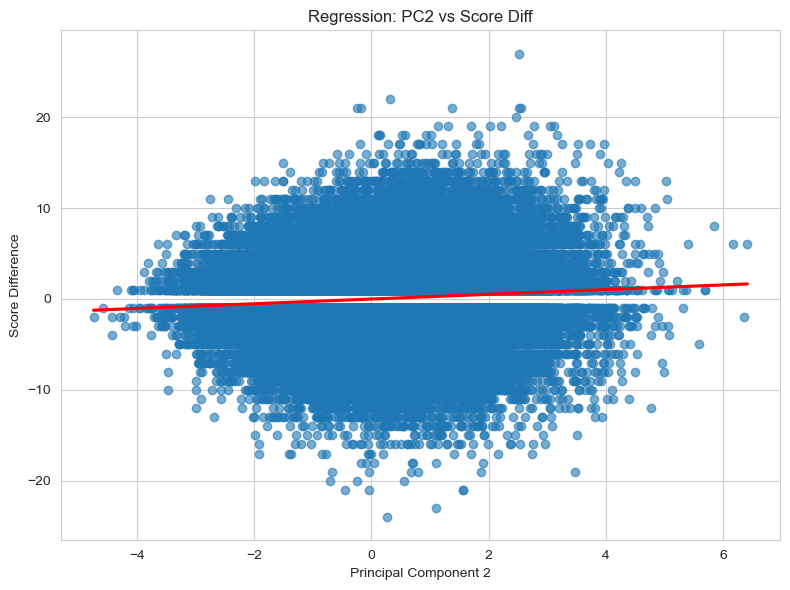

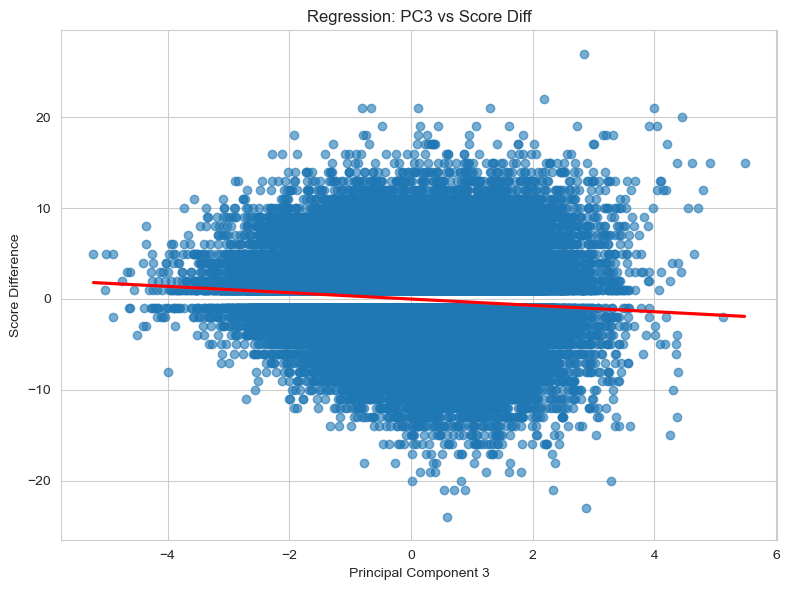

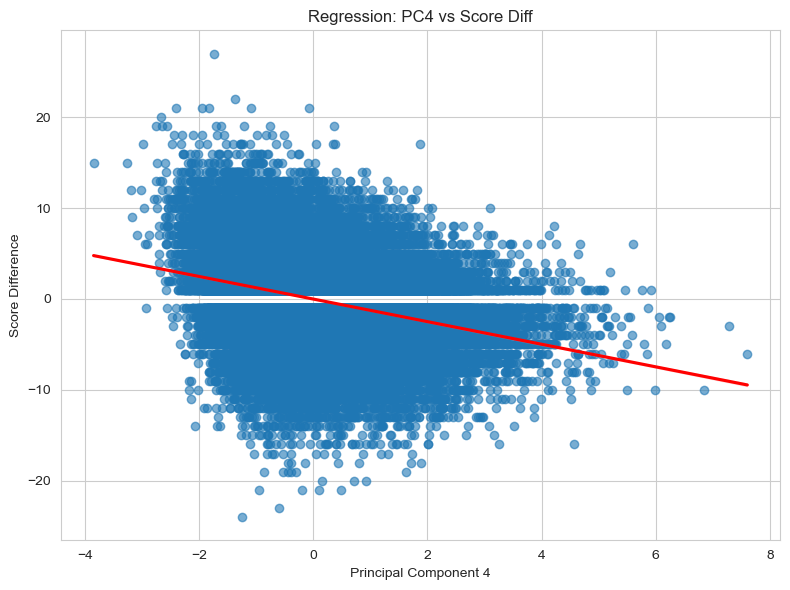

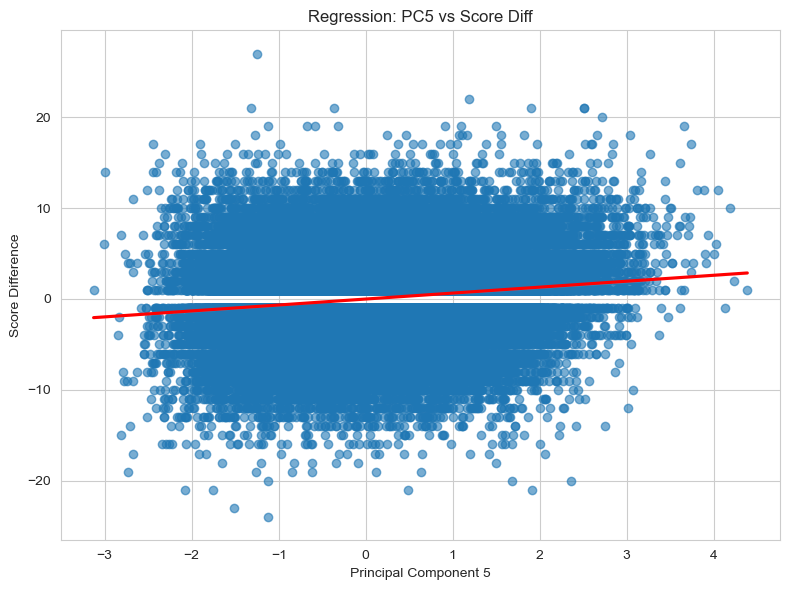

In [50]:
# plot
for pca_com in range(pca.n_components_):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    sns.regplot(x=X_pca[:, pca_com], y=y, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title(f"Regression: PC{pca_com + 1} vs Score Diff")
    plt.xlabel(f"Principal Component {pca_com + 1}")
    plt.ylabel("Score Difference")
    plt.tight_layout()
    plt.show()

In [51]:
print(X_pca.shape, y.shape)

(72968, 5) (72968,)


In [54]:
# fit linear regression model and plot results
from statsmodels.formula.api import ols

pca_col_names = [f"PCA_{i}" for i in range(X_pca.shape[1])]
df_data = pd.DataFrame(X_pca, columns=pca_col_names)
df_categorical = df[categorical_columns + [target]]
df_categorical = df_categorical.reset_index(drop=True)
df_data = df_data.reset_index(drop=True)
df_data = pd.concat([df_data, df_categorical], axis=1)
# # save df_data
df_data.to_csv("../CleanData/train_data_with_pca.csv", index=False)
#
df_data

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,gid,visteam,hometeam,site,wteam,lteam,date,teamID,yearID,score_diff
0,0.313597,0.021359,-1.974675,-0.065437,0.848299,PHI198908200,SFN,PHI,PHI12,SFN,PHI,1989-08-20,SFN,1989,3
1,-0.520790,-2.292432,1.722313,-0.516068,1.161302,CHA200908190,KCA,CHA,CHI12,CHA,KCA,2009-08-19,KCA,2009,-2
2,1.384424,0.721741,-0.454990,0.257168,1.975190,CLE199709271,MIN,CLE,CLE08,CLE,MIN,1997-09-27,CLE,1997,4
3,-0.412239,-0.610474,1.107978,1.142899,-0.712794,SFN200907090,SDN,SFN,SFO03,SFN,SDN,2009-07-09,SDN,2009,-6
4,-1.935892,2.234966,0.812038,-1.909305,0.557434,CHA198705260,KCA,CHA,CHI10,KCA,CHA,1987-05-26,KCA,1987,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72963,-1.259166,-1.277621,0.004456,-0.622833,1.376238,TBA201308180,TOR,TBA,STP01,TBA,TOR,2013-08-18,TOR,2013,-1
72964,-0.549035,1.611756,-0.813012,0.195779,-0.553411,CIN200204030,CHN,CIN,CIN08,CHN,CIN,2002-04-03,CIN,2002,-7
72965,0.114574,-1.623696,-1.090488,1.713059,0.352464,SLN201509050,PIT,SLN,STL10,SLN,PIT,2015-09-05,PIT,2015,-3
72966,-0.032560,-1.817952,1.544286,-0.256594,-0.233988,DET200607190,CHA,DET,DET05,DET,CHA,2006-07-19,CHA,2006,-3


In [141]:
formula = f"score_diff ~ {' + '.join(pca_col_names)} + visteam + hometeam + 0"
print(formula)
lr_model = ols(formula, data=df_train).fit()
# print(lr_model.params)
print(lr_model.summary())

score_diff ~ PCA_0 + PCA_1 + PCA_2 + PCA_3 + PCA_4 + visteam + hometeam + 0
                            OLS Regression Results                            
Dep. Variable:             score_diff   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     239.6
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        23:02:41   Log-Likelihood:            -2.0361e+05
No. Observations:               72967   AIC:                         4.074e+05
Df Residuals:                   72897   BIC:                         4.080e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [142]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Step 1: Calculate performance metrics
y_pred = lr_model.predict(df_test)
y_test = df_test['score_diff']
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Step 2: Print evaluation metrics
print(f"R² Score: {r2:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")

R² Score: 0.183
Mean Squared Error (MSE): 15.256
Root Mean Squared Error (RMSE): 3.906
Mean Absolute Error (MAE): 3.025


In [143]:
# try to predict a winner based on score_diff
df_test = df_test.assign(
    score_diff_pred = lr_model.predict(df_test)
)
correct_pred = 0
incorrect_pred = 0
for i, row in df_test.iterrows():
    if row['score_diff_pred'] > 0 and row['score_diff'] > 0:
        correct_pred += 1
    elif row['score_diff_pred'] < 0 and row['score_diff'] < 0:
        correct_pred += 1
    else:
        incorrect_pred += 1

print("Correct Predictions:", correct_pred, "Incorrect predictions:", incorrect_pred)
print("Percentage of correct pred (accuracy):", correct_pred / (correct_pred + incorrect_pred))


Correct Predictions: 12018 Incorrect predictions: 6224
Percentage of correct pred (accuracy): 0.6588093410810218


using one hot encoding for `site`

In [144]:
site_dummies = pd.get_dummies(df_data['site'], prefix='site')
df_data_no_site = df_data[[col for col in df_data.columns if col != "site"]]

# combine new dataframes into one
df_data_site_onehot = pd.concat([df_data_no_site, site_dummies], axis=1)
# save df_data
df_data_site_onehot.to_csv("../CleanData/df_data_with_pca_site_onehot.csv", index=False)
df_data_site_onehot.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,gid,visteam,hometeam,wteam,lteam,...,site_STL09,site_STL10,site_STP01,site_SYD01,site_TOK01,site_TOR01,site_TOR02,site_WAS10,site_WAS11,site_WIL02
0,-1.798157,-0.371419,-0.034352,0.946159,2.051056,BAL198504080,TEX,BAL,BAL,TEX,...,False,False,False,False,False,False,False,False,False,False
1,-1.030265,-0.507582,-0.129976,0.428520,1.706731,BOS198504080,NYA,BOS,BOS,NYA,...,False,False,False,False,False,False,False,False,False,False
2,-0.952697,-0.617817,2.435941,-0.058040,2.998030,CIN198504080,MON,CIN,CIN,MON,...,False,False,False,False,False,False,False,False,False,False
3,-0.665617,-0.063812,1.663154,1.139868,2.024773,DET198504080,CLE,DET,DET,CLE,...,False,False,False,False,False,False,False,False,False,False
4,-1.757698,0.150974,0.860254,0.623820,1.532551,KCA198504080,TOR,KCA,KCA,TOR,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_train, df_test = train_test_split(df_data_site_onehot, test_size=0.2, random_state=123)
# train_data = pd.concat([X_train, y_train], axis=1)
df_train.head()
formula = f"score_diff ~ {' + '.join(pca_col_names)} + hometeam + visteam + yearID + 0"
print(formula)
lr_model = ols(formula, data=df_train).fit()
# print(lr_model.params)
print(lr_model.summary())

In [112]:
# try to predict a winner based on score_diff
df_test = df_test.assign(
    score_diff_pred = lr_model.predict(df_test)
)
correct_pred = 0
incorrect_pred = 0
for i, row in df_test.iterrows():
    if row['score_diff_pred'] > 0 and row['score_diff'] > 0:
        correct_pred += 1
    elif row['score_diff_pred'] < 0 and row['score_diff'] < 0:
        correct_pred += 1
    else:
        incorrect_pred += 1

print("Correct Predictions:", correct_pred, "Incorrect predictions:", incorrect_pred)
print("Percentage of correct pred:", correct_pred / (correct_pred + incorrect_pred))

Correct Predictions: 12018 Incorrect predictions: 6224
Percentage of correct pred: 0.6588093410810218
